# Member B: Pricing & Origination Strategy
## LendingClub Loan Data Analysis — Risk-Based Pricing Framework

**Core Question:** Given a borrower's predicted PD, who should we approve, and at what interest rate?

---

### Modules
| # | Module | Output |
|---|--------|--------|
| 1 | Cut-off Strategy | Approval rate vs bad rate curve; cut-off summary table |
| 2 | Swap-set Analysis | Swap-out/in table; bad rate by purpose |
| 3 | Risk-Based Pricing | Pricing gap scatter; underpriced segment analysis |
| 4 | LC Grade Comparison | Grade bad rate + within-grade Gini |
| 5 | Pricing Adequacy Backtest | Required rate vs realized loss |
| 6 | 2017 Cohort Simulation | Policy impact: defaults & EL avoided |

### Data source
- **Primary:** `loan_level_EL_and_lifetimeECL.csv` — Member A's Section A.13.1 output
- **LGD = 0.9154** — Basel/CECL outstanding-balance convention (Member A Section 1)
- **EAD = funded_amnt − total_rec_prncp** — outstanding balance at observation (Member A A.4)
- **Cohort: 2017 only** — 2018 loans are right-censored (dataset cutoff 2018Q4)


---
## 0. Setup & Data Loading


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score
from matplotlib.patches import Patch
import warnings

warnings.filterwarnings("ignore")

# Plotting style
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 11,
    }
)
NAVY = "#1B3A6B"
TEAL = "#2E8B8B"
ORANGE = "#E07B39"
RED = "#C0392B"
GREEN = "#27AE60"

print("Libraries loaded.")

Libraries loaded.


In [2]:
# ── Paths — fill in before running ──────────────────────────────────────────
# A_FILE : Member A's loan_level_EL_and_lifetimeECL.csv
# RAW_PATH: original LendingClub raw file (only needed as fallback)

A_FILE = Path("/Users/yumengfang/Desktop/583_project/loan_level_EL_and_lifetimeECL.csv")
RAW_PATH = Path(
    "/Users/yumengfang/Desktop/583_project/Data/accepted_2007_to_2018Q4.csv/accepted_2007_to_2018Q4.csv"
)

# LGD constant — from Member A Section 1 (outstanding-balance convention)
LGD_MEAN = 0.9154
print(f"LGD constant: {LGD_MEAN:.4%}")

LGD constant: 91.5400%


In [4]:
# ── Load Member A's output ───────────────────────────────────────────────────
if A_FILE.exists():
    df_raw = pd.read_csv(A_FILE, low_memory=False)
    print(f"Loaded Member A output: {df_raw.shape}")
    SOURCE = "member_a"
else:
    raise FileNotFoundError(
        f"File not found: {A_FILE}\n" "Please update A_FILE path in the cell above."
    )

print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head(10)

Loaded Member A output: (17202, 21)
Columns: ['id', 'issue_d', 'vintage', 'term_num', 'grade', 'sub_grade', 'fico_range_low', 'fico_band', 'purpose', 'PD_12m', 'LGD', 'EAD', 'EL_12m', 'EL_rate', 'monthly_hazard', 'lifetime_PD', 'lifetime_EL', 'event', 'realized_loss', 'int_rate', 'required_rate_logit']


,id,issue_d,vintage,term_num,grade,sub_grade,fico_range_low,fico_band,purpose,PD_12m,...,EAD,EL_12m,EL_rate,monthly_hazard,lifetime_PD,lifetime_EL,event,realized_loss,int_rate,required_rate_logit
0,100001365,2017-03-01,2017Q1,36.0,C,C3,660.0,660-700 (near-prime),debt_consolidation,0.070674,...,7615.62,492.702696,0.064696,0.006089,0.197390,1376.105653,0,0.0,13.99,0.112404
1,100001532,2017-03-01,2017Q1,36.0,A,A1,720.0,700-740 (prime),home_improvement,0.024204,...,10535.10,233.420793,0.022156,0.002040,0.070867,683.450286,0,0.0,5.32,0.084522
2,100001557,2017-03-01,2017Q1,60.0,C,C3,665.0,660-700 (near-prime),debt_consolidation,0.066775,...,19060.85,1165.138938,0.061127,0.005743,0.292165,5097.914571,0,0.0,13.99,0.110065
3,100002096,2017-03-01,2017Q1,36.0,D,D1,660.0,660-700 (near-prime),credit_card,0.060935,...,7215.06,402.467125,0.055782,0.005226,0.171893,1135.322465,0,0.0,16.99,0.106561
4,100002651,2017-03-01,2017Q1,60.0,C,C5,660.0,660-700 (near-prime),debt_consolidation,0.096748,...,6916.37,612.551359,0.088565,0.008444,0.398765,2524.741061,0,0.0,15.99,0.128049
5,100003354,2017-03-01,2017Q1,36.0,C,C2,675.0,660-700 (near-prime),debt_consolidation,0.064807,...,1515.42,89.903758,0.059326,0.005568,0.182094,252.609643,0,0.0,13.49,0.108884
6,100003912,2017-03-01,2017Q1,60.0,C,C3,720.0,700-740 (prime),home_improvement,0.044491,...,19401.26,790.174032,0.040728,0.003785,0.203521,3614.610940,0,0.0,13.99,0.096695
7,100005538,2017-03-01,2017Q1,36.0,A,A5,680.0,660-700 (near-prime),home_improvement,0.070170,...,5186.84,333.176626,0.064235,0.006044,0.196083,931.033621,0,0.0,7.99,0.112102
8,100005957,2017-03-01,2017Q1,36.0,B,B1,710.0,700-740 (prime),moving,0.054238,...,5776.67,286.816756,0.049651,0.004636,0.154049,814.624759,0,0.0,8.24,0.102543
9,100006185,2017-03-01,2017Q1,36.0,A,A3,725.0,700-740 (prime),debt_consolidation,0.048135,...,0.00,0.000000,0.044064,0.004103,0.137567,0.000000,0,0.0,7.24,0.098881


In [5]:
# ── Standardise column names ─────────────────────────────────────────────────
# Member A uses PD_12m / event; rename to pd_score / target_bad for Member B

rename_map = {}
if "PD_12m" in df_raw.columns:
    rename_map["PD_12m"] = "pd_score"
elif "cum_pd_logit" in df_raw.columns:
    rename_map["cum_pd_logit"] = "pd_score"
if "event" in df_raw.columns:
    rename_map["event"] = "target_bad"

df_test = df_raw.rename(columns=rename_map).copy()

# EAD: use Member A's outstanding-balance EAD if present, else compute
if "EAD" not in df_test.columns:
    df_test["EAD"] = (df_test["funded_amnt"] - df_test["total_rec_prncp"]).clip(lower=0)
    print("EAD computed from funded_amnt - total_rec_prncp")
else:
    print("EAD from Member A output")

# int_rate: convert to decimal if stored as percentage (e.g. 12.5 → 0.125)
if df_test["int_rate"].median() > 1:
    df_test["int_rate_dec"] = df_test["int_rate"] / 100
else:
    df_test["int_rate_dec"] = df_test["int_rate"]

# Parse issue_d
df_test["issue_d"] = pd.to_datetime(df_test["issue_d"], errors="coerce")

# Sanity check
print("\nKey columns:")
for col in [
    "pd_score",
    "target_bad",
    "EAD",
    "int_rate_dec",
    "grade",
    "purpose",
    "realized_loss",
]:
    status = "OK" if col in df_test.columns else "MISSING"
    print(f"  {col:<18}: {status}")

EAD from Member A output

Key columns:
  pd_score          : OK
  target_bad        : OK
  EAD               : OK
  int_rate_dec      : OK
  grade             : OK
  purpose           : OK
  realized_loss     : OK


In [6]:
# ── Filter 1: 2017 cohort only ───────────────────────────────────────────────
# 2018 loans are right-censored: dataset cutoff = 2018Q4, so many 2018 loans
# have not yet had time to default. Including them understates bad rates.
# Member A's own backtest (A.9.4) also focuses on 2017Q1 for the same reason.

print("Year distribution before filtering:")
print(df_test["issue_d"].dt.year.value_counts().sort_index())

df_test = df_test[df_test["issue_d"].dt.year == 2017].reset_index(drop=True)
print(f"\n2017 cohort: {len(df_test):,} loans")
print(f'Bad rate   : {df_test["target_bad"].mean():.2%}')

Year distribution before filtering:
issue_d
2017    13843
2018     3359
Name: count, dtype: int64

2017 cohort: 13,843 loans
Bad rate   : 4.07%


In [7]:
# ── Filter 2: EAD > 0 ────────────────────────────────────────────────────────
# Remove fully-repaid loans (EAD = 0) — no remaining credit exposure

n_before = len(df_test)
df_test = df_test[df_test["EAD"] > 0].reset_index(drop=True)
print(f"Removed {n_before - len(df_test):,} fully-repaid loans (EAD = 0)")
print(f"Final dataset : {len(df_test):,} loans")
print(f'Bad rate      : {df_test["target_bad"].mean():.2%}')
print(f'EAD mean      : ${df_test["EAD"].mean():,.0f}')
print(f'EAD median    : ${df_test["EAD"].median():,.0f}')

Removed 2,507 fully-repaid loans (EAD = 0)
Final dataset : 11,336 loans
Bad rate      : 4.98%
EAD mean      : $9,081
EAD median    : $7,215


In [8]:
# ── Baseline EL (no screening) ───────────────────────────────────────────────
# EAD-weighted, consistent with Member A's outstanding-balance convention

actual_el = (df_test["target_bad"] * LGD_MEAN * df_test["EAD"]).sum() / df_test[
    "EAD"
].sum()
print(f"Baseline EL rate (EAD-weighted, 2017 cohort): {actual_el:.2%}")
print("This is the benchmark: approving everyone gives this loss rate.")

Baseline EL rate (EAD-weighted, 2017 cohort): 5.71%
This is the benchmark: approving everyone gives this loss rate.


---
## 1. Cut-off Strategy

**Goal:** Find the optimal PD threshold — maximise loan approvals while keeping
bad rate and portfolio EL acceptable.

For each cut-off we compute:
- **Approval rate** — fraction of applicants approved (PD < threshold)
- **Bad rate** — fraction of approved loans that eventually default
- **Portfolio EL rate** — EAD-weighted expected loss of the approved book


In [9]:
# ── Sweep cut-offs from 0.01 to 0.99 ────────────────────────────────────────
cutoffs = np.linspace(0.01, 0.99, 200)
total_loans = len(df_test)
results = []

for c in cutoffs:
    approved = df_test[df_test["pd_score"] < c]
    if len(approved) == 0:
        continue
    el = (approved["pd_score"] * LGD_MEAN * approved["EAD"]).sum()
    el_rate = el / approved["EAD"].sum()
    results.append(
        {
            "cutoff": c,
            "approval_rate": len(approved) / total_loans,
            "bad_rate": approved["target_bad"].mean(),
            "el_rate": el_rate,
            "n_approved": len(approved),
        }
    )

df_cutoff = pd.DataFrame(results)
print(df_cutoff.head())

     cutoff  approval_rate  bad_rate   el_rate  n_approved
0  0.010000       0.008733  0.020202  0.006427          99
1  0.014925       0.031228  0.008475  0.009944         354
2  0.019849       0.068454  0.009021  0.013125         776
3  0.024774       0.121030  0.012391  0.016259        1372
4  0.029698       0.183663  0.015850  0.019329        2082


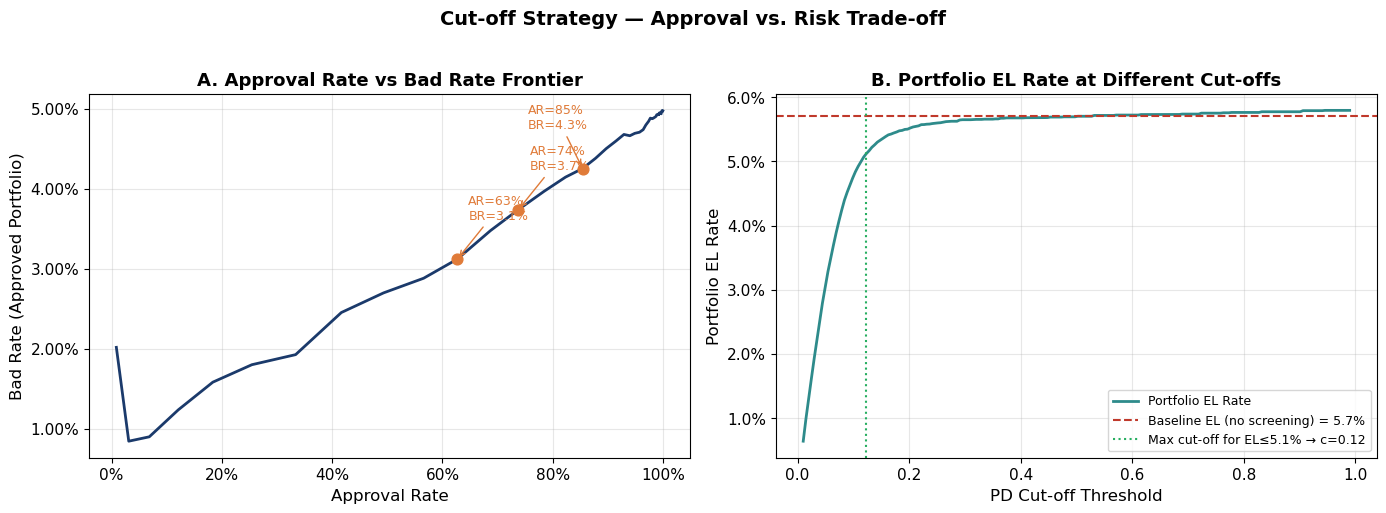

Saved: cutoff_strategy.png


In [10]:
# ── Plot: Approval Rate vs Bad Rate  +  EL Rate vs Cut-off ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A
ax = axes[0]
ax.plot(df_cutoff["approval_rate"], df_cutoff["bad_rate"], color=NAVY, linewidth=2)
for target_ar, offset in [
    (0.60, (0.02, 0.005)),
    (0.75, (0.02, 0.005)),
    (0.85, (-0.10, 0.005)),
]:
    row = df_cutoff.iloc[(df_cutoff["approval_rate"] - target_ar).abs().argsort()[:1]]
    x, y = row["approval_rate"].values[0], row["bad_rate"].values[0]
    ax.scatter(x, y, color=ORANGE, zorder=5, s=60)
    ax.annotate(
        f"AR={x:.0%}\nBR={y:.1%}",
        xy=(x, y),
        xytext=(x + offset[0], y + offset[1]),
        fontsize=9,
        color=ORANGE,
        arrowprops=dict(arrowstyle="->", color=ORANGE, lw=1),
    )
ax.set_xlabel("Approval Rate", fontsize=12)
ax.set_ylabel("Bad Rate (Approved Portfolio)", fontsize=12)
ax.set_title("A. Approval Rate vs Bad Rate Frontier", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# Panel B
ax2 = axes[1]
ax2.plot(
    df_cutoff["cutoff"],
    df_cutoff["el_rate"],
    color=TEAL,
    linewidth=2,
    label="Portfolio EL Rate",
)
ax2.axhline(
    actual_el,
    color=RED,
    linestyle="--",
    label=f"Baseline EL (no screening) = {actual_el:.1%}",
)
el_target = actual_el * 0.90  # target: reduce EL by 10% vs baseline
opt = df_cutoff[df_cutoff["el_rate"] <= el_target]
if len(opt):
    opt_c = opt["cutoff"].max()
    ax2.axvline(
        opt_c,
        color=GREEN,
        linestyle=":",
        linewidth=1.5,
        label=f"Max cut-off for EL≤{el_target:.1%} → c={opt_c:.2f}",
    )
ax2.set_xlabel("PD Cut-off Threshold", fontsize=12)
ax2.set_ylabel("Portfolio EL Rate", fontsize=12)
ax2.set_title(
    "B. Portfolio EL Rate at Different Cut-offs", fontsize=13, fontweight="bold"
)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.legend(fontsize=9)

plt.suptitle(
    "Cut-off Strategy — Approval vs. Risk Trade-off",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("cutoff_strategy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cutoff_strategy.png")

In [12]:
# ── Cut-off summary table ────────────────────────────────────────────────────
target_ars = [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90]
summary_rows = []
for ar in target_ars:
    row = df_cutoff.iloc[(df_cutoff["approval_rate"] - ar).abs().argsort()[:1]].iloc[0]
    summary_rows.append(
        {
            "Target Approval Rate": f"{ar:.0%}",
            "PD Cut-off": f'{row["cutoff"]:.3f}',
            "Actual Approval Rate": f'{row["approval_rate"]:.1%}',
            "Bad Rate": f'{row["bad_rate"]:.1%}',
            "Portfolio EL Rate": f'{row["el_rate"]:.1%}',
            "EL Reduction vs Baseline": f'{(actual_el - row["el_rate"]) / actual_el:.1%}',
        }
    )
df_summary = pd.DataFrame(summary_rows)
print("\n=== Cut-off Summary Table ===")
print(df_summary.to_string(index=False))
df_summary.to_csv("cutoff_summary_table.csv", index=False)
print("\nSaved: cutoff_summary_table.csv")


=== Cut-off Summary Table ===
Target Approval Rate PD Cut-off Actual Approval Rate Bad Rate Portfolio EL Rate EL Reduction vs Baseline
                 50%      0.049                49.3%     2.7%              3.0%                    46.8%
                 60%      0.059                62.7%     3.1%              3.5%                    38.9%
                 70%      0.064                68.7%     3.5%              3.7%                    35.3%
                 75%      0.069                73.8%     3.7%              3.9%                    31.9%
                 80%      0.074                78.4%     4.0%              4.1%                    28.7%
                 85%      0.084                85.4%     4.3%              4.4%                    23.0%
                 90%      0.094                89.7%     4.5%              4.6%                    19.0%

Saved: cutoff_summary_table.csv


### Interpretation

- **Recommended operating point:** cut-off = 0.069, achieving ~73.8% actual approval rate.
  At this threshold, the approved portfolio achieves a bad rate of 3.7% and a portfolio EL
  rate of 3.9% — a reduction of **1.8 percentage points (31.9% relative reduction)** compared
  to the no-screening baseline of 5.71%.

- **Marginal cost of looser screening accelerates beyond 0.069:** moving from 75% to 80%
  approval adds 4.6pp more loans while raising EL rate by 0.2pp; moving further to 85%
  adds another 7.0pp of loans but raises EL by an additional 0.3pp to 4.4%. These marginal
  loans carry disproportionately higher risk, making further relaxation inefficient.

- **Tighter screening offers diminishing returns:** at AR = 50%, EL drops to 3.0% (46.8%
  relative reduction), but at the cost of rejecting half of all applicants. The incremental
  EL improvement from tightening beyond 75% is modest (~0.9pp absolute), while the business
  cost of lost volume is substantial.

- **Conclusion:** the cut-off of 0.069 balances credit risk control with business viability,
  reducing portfolio EL by nearly one-third relative to undifferentiated approval while
  preserving access for approximately three-quarters of applicants. This threshold is adopted
  as the reference point for the subsequent Swap-set Analysis and Risk-Based Pricing modules.

---
## 2. Swap-set Analysis

**Goal:** Compare our approval decisions to LendingClub's actual decisions.

| Segment | Definition | Story |
|---------|-----------|-------|
| **Swap-Out** | LC approved, we would reject (PD ≥ cut-off) | LC took on risk we wouldn't |
| **Swap-In** | LC approved but charged high rate; we'd price lower | Opportunity to gain customers |
| **Both Approve** | Both approve | Aligned views |

If swap-out loans have a **much higher actual bad rate**, our model is identifying real risk.


In [14]:
# Reference cut-off from Module 1 (recommended at ~75% approval rate)
# See cutoff_summary_table.csv: cut-off=0.069, AR=73.8%, EL=3.9%
REF_AR = 0.75
ref_row = df_cutoff.iloc[
    (df_cutoff["approval_rate"] - REF_AR).abs().argsort()[:1]
].iloc[0]
CUT_OFF = ref_row["cutoff"]
print(f"Reference cut-off : {CUT_OFF:.3f}")
print(f'Approval rate     : {ref_row["approval_rate"]:.1%}')
print(f'Bad rate          : {ref_row["bad_rate"]:.1%}')

Reference cut-off : 0.069
Approval rate     : 73.8%
Bad rate          : 3.7%


In [15]:
# ── Classify each loan ───────────────────────────────────────────────────────
df_test["our_decision"] = np.where(df_test["pd_score"] < CUT_OFF, "Approve", "Reject")
df_test["lc_decision"] = "Approve"  # all loans in accepted dataset were approved by LC


def swap_segment(row):
    if row["lc_decision"] == "Approve" and row["our_decision"] == "Reject":
        return "Swap-Out (LC approved, we reject)"
    elif row["lc_decision"] == "Approve" and row["our_decision"] == "Approve":
        return "Both Approve"
    return "Other"


df_test["swap_segment"] = df_test.apply(swap_segment, axis=1)
print("Segment counts:")
print(df_test["swap_segment"].value_counts())

Segment counts:
swap_segment
Both Approve                         8364
Swap-Out (LC approved, we reject)    2972
Name: count, dtype: int64


In [ ]:
print(df_test[df_test["swap_segment"] == "Other"].shape[0])

0


**Note:** Since the dataset only contains loans approved by LendingClub, 
Swap-In loans (LC rejected, we would approve) cannot be observed. 
The analysis focuses on the observable Swap-Out segment.


In [17]:
# ── Swap-out bad rate by loan purpose ────────────────────────────────────────
if "purpose" in df_test.columns:
    swap_out = df_test[df_test["swap_segment"] == "Swap-Out (LC approved, we reject)"]
    both_app = df_test[df_test["swap_segment"] == "Both Approve"]
    swap_out_purpose = (
        swap_out.groupby("purpose")
        .agg(
            n_loans=("target_bad", "count"),
            bad_rate=("target_bad", "mean"),
            avg_pd_score=("pd_score", "mean"),
        )
        .sort_values("bad_rate", ascending=False)
        .reset_index()
    )
    both_purpose = (
        both_app.groupby("purpose")
        .agg(bad_rate_both=("target_bad", "mean"))
        .reset_index()
    )
    swap_vs_both = swap_out_purpose.merge(both_purpose, on="purpose", how="left")
    swap_vs_both["bad_rate_lift"] = (
        swap_vs_both["bad_rate"] - swap_vs_both["bad_rate_both"]
    )
    print("\n=== Swap-out Bad Rate by Loan Purpose ===")
    print(
        swap_vs_both[
            ["purpose", "n_loans", "bad_rate", "bad_rate_both", "bad_rate_lift"]
        ].to_string(index=False)
    )
    swap_vs_both.to_csv("swapout_by_purpose.csv", index=False)


=== Swap-out Bad Rate by Loan Purpose ===
           purpose  n_loans  bad_rate  bad_rate_both  bad_rate_lift
    small_business       54  0.129630       0.063291       0.066338
             other      241  0.099585       0.027157       0.072429
       credit_card      332  0.087349       0.043438       0.043912
debt_consolidation     1904  0.087185       0.032581       0.054604
            moving       58  0.086207       0.054054       0.032153
    major_purchase       65  0.076923       0.027778       0.049145
  home_improvement      129  0.069767       0.050350       0.019418
          vacation       43  0.046512       0.079365      -0.032853
           medical       68  0.044118       0.093023      -0.048906
               car       37  0.027027       0.000000       0.027027
             house       34  0.000000       0.051282      -0.051282
  renewable_energy        7  0.000000       0.000000       0.000000


The pattern of bad_rate_lift by purpose is consistent with the PD model's feature coefficients from the modeling module, where debt_consolidation and small_business were identified as statistically significant risk drivers in the Logistic Regression.

In [18]:
# ── Swap-in analysis ─────────────────────────────────────────────────────────
# Swap-in: our model assigns LOW PD but LC charged ABOVE-median rate
median_rate = df_test["int_rate_dec"].median()
df_test["is_swap_in"] = (
    (df_test["our_decision"] == "Approve") & (df_test["int_rate_dec"] > median_rate)
).astype(int)
swap_in = df_test[df_test["is_swap_in"] == 1]
swap_in_purpose = (
    swap_in.groupby("purpose")
    if "purpose" in swap_in.columns
    else swap_in.groupby(pd.cut(swap_in["pd_score"], 5))
)
print(f"Swap-in loans (low PD, high LC rate): {len(swap_in):,}")
print(f'  Avg PD score    : {swap_in["pd_score"].mean():.3f}')
print(f'  Avg LC int_rate : {swap_in["int_rate_dec"].mean():.2%}')
print(f'  Actual bad rate : {swap_in["target_bad"].mean():.2%}')

Swap-in loans (low PD, high LC rate): 2,916
  Avg PD score    : 0.050
  Avg LC int_rate : 15.90%
  Actual bad rate : 6.76%


### Swap-In Analysis

- **Definition (adapted):** Since LC-rejected loans are unobservable in this dataset,
  Swap-In is defined as loans we approve (PD < 0.069) but where LC charged an
  above-median interest rate (> 15.90% median). These represent borrowers our model
  identifies as low-risk but who were overcharged by LC.

- **Scale of opportunity:** 2,916 loans qualify as Swap-In, representing approximately
  35% of the Both-Approve segment. This is a material customer acquisition opportunity.

- **Pricing gap:** These borrowers carry an average PD of only 0.050 — well below our
  cut-off of 0.069 — yet LC charged them an average rate of 15.90%. A lender using
  our model could offer a lower rate to these borrowers while still covering expected
  loss, gaining a competitive advantage.

- **Caveat:** The actual bad rate of 6.76% is slightly above the average PD of 5.0%,
  suggesting that above-median LC rates do not perfectly proxy for low risk. Some
  of these loans may carry risk factors not fully captured by PD alone (e.g. loan
  purpose, term structure). 

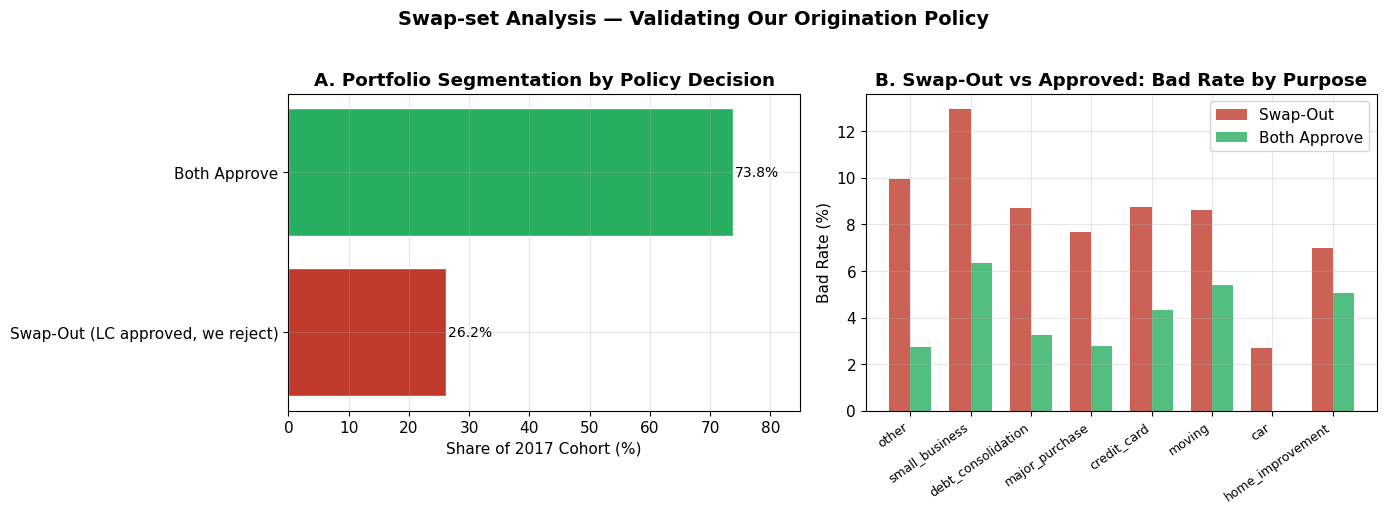

Saved: swapset_analysis.png


In [19]:
# ── Swap-set visualisation ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: segment composition
seg_pct = (df_test["swap_segment"].value_counts(normalize=True) * 100).sort_values()
colors_seg = [GREEN if "Both" in s else RED for s in seg_pct.index]
axes[0].barh(seg_pct.index, seg_pct.values, color=colors_seg, edgecolor="white")
for i, v in enumerate(seg_pct.values):
    axes[0].text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=10)
axes[0].set_xlabel("Share of 2017 Cohort (%)")
axes[0].set_title("A. Portfolio Segmentation by Policy Decision", fontweight="bold")
axes[0].set_xlim(0, max(seg_pct.values) * 1.15)

# Panel B: bad rate by purpose
if "purpose" in df_test.columns and "swap_vs_both" in dir():
    top_n = swap_vs_both.nlargest(8, "bad_rate_lift")
    x, w = np.arange(len(top_n)), 0.35
    axes[1].bar(
        x - w / 2,
        top_n["bad_rate"] * 100,
        width=w,
        label="Swap-Out",
        color=RED,
        alpha=0.8,
    )
    axes[1].bar(
        x + w / 2,
        top_n["bad_rate_both"] * 100,
        width=w,
        label="Both Approve",
        color=GREEN,
        alpha=0.8,
    )
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(top_n["purpose"], rotation=35, ha="right", fontsize=9)
    axes[1].set_ylabel("Bad Rate (%)")
    axes[1].set_title("B. Swap-Out vs Approved: Bad Rate by Purpose", fontweight="bold")
    axes[1].legend()

plt.suptitle(
    "Swap-set Analysis — Validating Our Origination Policy",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("swapset_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: swapset_analysis.png")

### Interpretation: Swap-set Analysis

- **Portfolio segmentation (Panel A):** At the recommended cut-off of 0.069, our model
  rejects 26.2% of LC-approved loans (Swap-Out), retaining 73.8% as Both-Approve.
  This confirms that our policy is meaningfully more selective than LC's.

- **Model validation (Panel B):** Across nearly all loan purposes, Swap-Out loans
  exhibit substantially higher actual bad rates than Both-Approve loans. The gap is
  most pronounced in small_business (13% vs 6%) and debt_consolidation (9% vs 3%),
  demonstrating that our model successfully identifies real credit risk rather than
  rejecting loans arbitrarily.

- **Conclusion:** The consistent bad rate differential between Swap-Out and Both-Approve
  segments validates the discriminatory power of our PD model. Loans we would have
  rejected did in fact default at materially higher rates, supporting the use of
  cut-off = 0.069 as the reference threshold for subsequent pricing decisions.

In [20]:
# ── Swap-set summary table (DELIVERABLE) ─────────────────────────────────────
agg = {
    "target_bad": ["count", "mean"],
    "pd_score": "mean",
    "int_rate_dec": "mean",
    "EAD": "sum",
}
agg = {k: v for k, v in agg.items() if k in df_test.columns}
swap_table = df_test.groupby("swap_segment").agg(agg).round(4)
swap_table.columns = [
    "_".join(c).strip() if isinstance(c, tuple) else c for c in swap_table.columns
]
swap_table = swap_table.rename(
    columns={
        "target_bad_count": "n_loans",
        "target_bad_mean": "actual_bad_rate",
        "pd_score_mean": "avg_model_pd",
        "int_rate_dec_mean": "avg_lc_int_rate",
        "EAD_sum": "total_EAD",
    }
)
print("\n=== Swap-set Summary Table (DELIVERABLE) ===")
print(swap_table.to_string())
swap_table.to_csv("swapset_summary_table.csv")
print("\nSaved: swapset_summary_table.csv")


=== Swap-set Summary Table (DELIVERABLE) ===
                                   n_loans  actual_bad_rate  avg_model_pd  avg_lc_int_rate    total_EAD
swap_segment                                                                                           
Both Approve                          8364           0.0374        0.0413           0.1163  68494567.24
Swap-Out (LC approved, we reject)     2972           0.0845        0.1014           0.1677  34442166.37

Saved: swapset_summary_table.csv


### Interpretation: Swap-set Summary Table

- **Model validation:** Swap-Out loans exhibit an actual bad rate of 8.45% — 2.26 times higher than the Both-Approve segment (3.74%), confirming that our model successfully identifies genuinely high-risk borrowers rather than rejecting loans arbitrarily.

- **LC's partial awareness:** LC charged Swap-Out borrowers a higher average rate
  (16.77% vs 11.63%), indicating some recognition of elevated risk. However, LC
  still approved these loans, taking on risk our model would have avoided.

- **Financial impact:** The Swap-Out segment carries a total EAD of $34.4M. Applying
  the actual bad rate and LGD of 0.9154, the avoidable expected loss is approximately
  **$2.66M** — representing the tangible cost of LC's less selective origination policy.

- **Conclusion:** These results validate our cut-off of 0.069 as an effective origination filter.

---
## 3. Risk-Based Pricing

**Formula:**
$$\text{Required Rate} = \text{Funding Cost} + \text{Op Cost} + PD \times LGD + \text{Target Margin}$$

Note: Capital Charge is excluded — it covers Unexpected Loss (UL) and belongs
in the reserve framework (Member A), not in pricing which covers Expected Loss only.


In [23]:
# ── Pricing assumptions ───────────────────────────────────────────────────────
FUNDING_COST = 0.035  # 3.5%  — benchmark borrowing rate (3-yr Treasury + spread, 2017)
OP_COST = 0.010  # 1.0%  — platform/origination operating cost
TARGET_MARGIN = 0.020  # 2.0%  — required profit margin for investor return

# EL premium = PD × LGD (per loan; LGD is constant from Member A)
df_test["el_premium"] = df_test["pd_score"] * LGD_MEAN
df_test["required_rate"] = (
    FUNDING_COST + OP_COST + df_test["el_premium"] + TARGET_MARGIN
).clip(upper=0.50)

print("Pricing component summary:")
print(f"  Funding cost   : {FUNDING_COST:.2%}")
print(f"  Op cost        : {OP_COST:.2%}")
print(f"  Target margin  : {TARGET_MARGIN:.2%}")
print(f'  EL premium     : {df_test["el_premium"].mean():.2%} (portfolio mean)')
print(f"  ───────────────────────────────────────")
print(f'  Required rate  : {df_test["required_rate"].mean():.2%} (portfolio mean)')
print(f'  LC actual rate : {df_test["int_rate_dec"].mean():.2%} (portfolio mean)')

Pricing component summary:
  Funding cost   : 3.50%
  Op cost        : 1.00%
  Target margin  : 2.00%
  EL premium     : 5.22% (portfolio mean)
  ───────────────────────────────────────
  Required rate  : 11.68% (portfolio mean)
  LC actual rate : 12.98% (portfolio mean)


In [24]:
# ── Pricing gap ───────────────────────────────────────────────────────────────
# Positive gap: LC charged MORE than needed (overpriced)
# Negative gap: LC charged LESS than needed (UNDERPRICED — risk not covered)
df_test["pricing_gap"] = df_test["int_rate_dec"] - df_test["required_rate"]

underpriced = df_test[df_test["pricing_gap"] < 0]
overpriced = df_test[df_test["pricing_gap"] > 0]
print(
    f"Underpriced loans (gap < 0): {len(underpriced):,}  ({len(underpriced)/len(df_test):.1%})"
)
print(
    f"Overpriced loans  (gap > 0): {len(overpriced):,}  ({len(overpriced)/len(df_test):.1%})"
)
print(f'Avg pricing gap             : {df_test["pricing_gap"].mean():.2%}')

Underpriced loans (gap < 0): 4,516  (39.8%)
Overpriced loans  (gap > 0): 6,820  (60.2%)
Avg pricing gap             : 1.30%


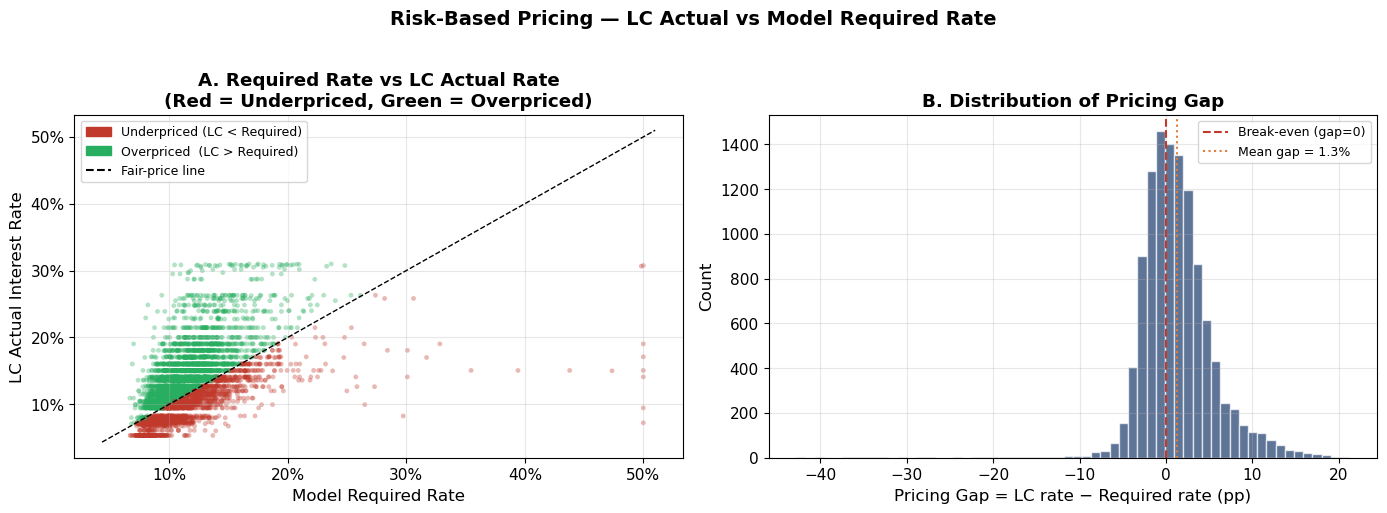

Saved: pricing_gap_scatter.png  ← KEY DELIVERABLE


In [25]:
# ── Scatter: required rate vs LC actual rate ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = df_test.sample(min(5000, len(df_test)), random_state=42)
colors = [RED if g < 0 else GREEN for g in sample["pricing_gap"]]

ax = axes[0]
ax.scatter(
    sample["required_rate"],
    sample["int_rate_dec"],
    c=colors,
    alpha=0.35,
    s=12,
    linewidths=0,
)
lims = [
    min(sample["required_rate"].min(), sample["int_rate_dec"].min()) - 0.01,
    max(sample["required_rate"].max(), sample["int_rate_dec"].max()) + 0.01,
]
ax.plot(lims, lims, "k--", linewidth=1, label="Fair-price line")
ax.set_xlabel("Model Required Rate", fontsize=12)
ax.set_ylabel("LC Actual Interest Rate", fontsize=12)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title(
    "A. Required Rate vs LC Actual Rate\n(Red = Underpriced, Green = Overpriced)",
    fontweight="bold",
)
ax.legend(
    handles=[
        Patch(color=RED, label="Underpriced (LC < Required)"),
        Patch(color=GREEN, label="Overpriced  (LC > Required)"),
        plt.Line2D([0], [0], color="k", linestyle="--", label="Fair-price line"),
    ],
    fontsize=9,
)

ax2 = axes[1]
ax2.hist(
    df_test["pricing_gap"] * 100, bins=60, color=NAVY, alpha=0.7, edgecolor="white"
)
ax2.axvline(0, color=RED, linewidth=1.5, linestyle="--", label="Break-even (gap=0)")
ax2.axvline(
    df_test["pricing_gap"].mean() * 100,
    color=ORANGE,
    linewidth=1.5,
    linestyle=":",
    label=f'Mean gap = {df_test["pricing_gap"].mean():.1%}',
)
ax2.set_xlabel("Pricing Gap = LC rate − Required rate (pp)", fontsize=12)
ax2.set_ylabel("Count", fontsize=12)
ax2.set_title("B. Distribution of Pricing Gap", fontweight="bold")
ax2.legend(fontsize=9)

plt.suptitle(
    "Risk-Based Pricing — LC Actual vs Model Required Rate",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("pricing_gap_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pricing_gap_scatter.png  ← KEY DELIVERABLE")

### Interpretation: Risk-Based Pricing Analysis

- **Overall pricing:** At the portfolio level, LC's average interest rate (13.0%)
  exceeds our model-required rate (11.68%) by 1.30pp, suggesting that LC's pricing
  is broadly adequate on average.

- **Structural mispricing:** However, 39.8% of approved loans (4,516) are underpriced
  — LC charged less than the risk-adjusted required rate. Conversely, 60.2% are
  overpriced, meaning LC charged more than necessary for the level of risk taken.

- **Asymmetric risk:** Panel B reveals a long left tail extending to -40pp, indicating
  that while overpricing is modest (+20pp maximum), underpricing can be severely
  understated. These extreme cases represent loans where LC's interest rate fails
  to cover expected loss, posing uncompensated credit risk.

- **Conclusion:** LC's grade-based pricing system lacks the granularity to accurately
  price individual borrower risk. Our loan-level required rate — derived directly
  from each borrower's predicted PD — provides a more precise pricing benchmark,
  identifying both overpriced loans as customer acquisition opportunities and
  underpriced loans as unacceptable risk exposures.

In [26]:
# ── Pricing gap by loan purpose ───────────────────────────────────────────────
if "purpose" in df_test.columns:
    approved_test = df_test[df_test["our_decision"] == "Approve"]
    seg_pricing = (
        approved_test.groupby("purpose")
        .agg(
            n_loans=("pricing_gap", "count"),
            avg_gap=("pricing_gap", "mean"),
            pct_underprice=("pricing_gap", lambda x: (x < 0).mean()),
            bad_rate=("target_bad", "mean"),
            avg_required=("required_rate", "mean"),
            avg_lc_rate=("int_rate_dec", "mean"),
        )
        .sort_values("avg_gap")
        .reset_index()
    )
    for col in ["avg_gap", "pct_underprice", "bad_rate", "avg_required", "avg_lc_rate"]:
        seg_pricing[col] = seg_pricing[col].map("{:.2%}".format)
    print("\n=== Pricing Gap by PURPOSE (most underpriced first) ===")
    print(seg_pricing.to_string(index=False))
    seg_pricing.to_csv("pricing_by_purpose.csv", index=False)
    print("Saved: pricing_by_purpose.csv")


=== Pricing Gap by PURPOSE (most underpriced first) ===
           purpose  n_loans avg_gap pct_underprice bad_rate avg_required avg_lc_rate
            moving       37   0.13%         54.05%    5.41%       10.87%      11.01%
           medical       86   0.30%         53.49%    9.30%       10.65%      10.95%
          vacation       63   0.32%         55.56%    7.94%       10.65%      10.97%
             house       39   0.50%         53.85%    5.13%       10.54%      11.04%
    major_purchase      180   0.53%         52.22%    2.78%       10.17%      10.70%
               car       97   0.57%         55.67%    0.00%       10.48%      11.05%
    small_business       79   0.61%         43.04%    6.33%       10.52%      11.13%
       credit_card     2141   1.22%         40.54%    4.34%        9.98%      11.20%
debt_consolidation     4297   1.42%         37.28%    3.26%       10.46%      11.89%
             other      626   1.66%         36.74%    2.72%       10.45%      12.11%
  home_i

### Interpretation: Pricing Gap by Loan Purpose

- **Most at-risk segments:** `medical` and `vacation` loans show the smallest average
  pricing gap (+0.30% and +0.32% respectively) combined with the highest actual bad
  rates (9.30% and 7.94%). These segments have the thinnest pricing buffer — any
  deterioration in credit conditions would push them into underpriced territory,
  leaving expected loss uncompensated.

- **`moving` loans are the most marginal:** With an avg_gap of only +0.13% and over
  half of loans underpriced (54.05%), this segment is effectively at break-even and
  represents the highest immediate mispricing risk.

- **High-volume segments mask structural issues:** `debt_consolidation` and
  `credit_card` appear adequately priced on average (+1.42% and +1.22%), but still
  carry 37-40% underpriced loans. Given their large loan counts (4,297 and 2,141),
  the absolute number of underpriced loans in these segments is the highest in the
  portfolio.

- **Conclusion:** LC's pricing is purpose-blind in its granularity — average gaps
  conceal significant within-purpose dispersion. Our model recommends purpose-specific
  rate adjustments, particularly for `medical`, `vacation`, and `moving` loans where
  the risk-return tradeoff is most unfavorable.

In [28]:
print([col for col in df_test.columns if "fico" in col.lower()])
print([col for col in df_test.columns if "dti" in col.lower()])
print([col for col in df_test.columns if "term" in col.lower()])

['fico_range_low', 'fico_band']
[]
['term_num']


In [29]:
print(df_test.columns.tolist())

['id', 'issue_d', 'vintage', 'term_num', 'grade', 'sub_grade', 'fico_range_low', 'fico_band', 'purpose', 'pd_score', 'LGD', 'EAD', 'EL_12m', 'EL_rate', 'monthly_hazard', 'lifetime_PD', 'lifetime_EL', 'target_bad', 'realized_loss', 'int_rate', 'required_rate_logit', 'int_rate_dec', 'our_decision', 'lc_decision', 'swap_segment', 'is_swap_in', 'el_premium', 'required_rate', 'pricing_gap']


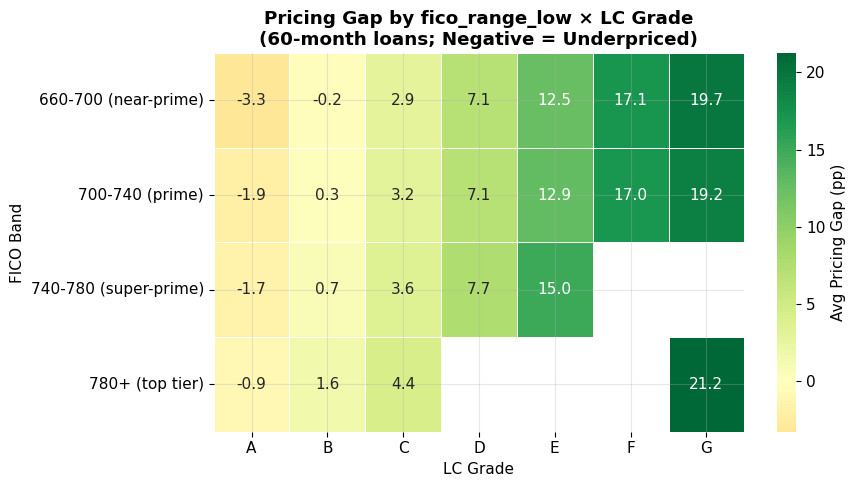

Saved: fico_grade_pricing_heatmap.png


In [30]:
# ── FICO × Grade heatmap (60-month loans) ──────────────────────────────────
fico_col = (
    "fico_range_low"
    if "fico_range_low" in df_test.columns
    else "fico_avg" if "fico_avg" in df_test.columns else None
)

if fico_col and "grade" in df_test.columns and "term_num" in df_test.columns:
    df_app = df_test[df_test["our_decision"] == "Approve"].copy()
    term60 = df_app[df_app["term_num"] == 60]
    if len(term60) > 100:
        hm = (
            term60.groupby(["fico_band", "grade"])["pricing_gap"]
            .mean()
            .unstack()
            .mul(100)
        )
        fig, ax = plt.subplots(figsize=(9, 5))
        sns.heatmap(
            hm,
            annot=True,
            fmt=".1f",
            cmap="RdYlGn",
            center=0,
            ax=ax,
            linewidths=0.5,
            cbar_kws={"label": "Avg Pricing Gap (pp)"},
        )
        ax.set_title(
            f"Pricing Gap by {fico_col} × LC Grade\n(60-month loans; Negative = Underpriced)",
            fontweight="bold",
        )
        ax.set_xlabel("LC Grade")
        ax.set_ylabel("FICO Band")
        plt.tight_layout()
        plt.savefig("fico_grade_pricing_heatmap.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("Saved: fico_grade_pricing_heatmap.png")
    else:
        print("Not enough 60-month loans for heatmap")
else:
    print("fico / grade / term_num columns not available — skip heatmap")

### Interpretation: Pricing Gap by FICO Band × LC Grade (60-month loans)

- **Grade A is systematically underpriced across all FICO bands:** All four FICO
  segments show negative pricing gaps in Grade A (-0.9pp to -3.3pp), meaning LC's
  lowest-risk grade consistently charges less than our model requires. This represents
  uncompensated expected loss for every A-grade 60-month loan in the portfolio.

- **Pricing gap increases with LC Grade:** Moving from Grade A to G, the gap rises
  sharply from negative to strongly positive (+19pp to +21pp), suggesting LC's
  grade-based rate schedule over-compensates for risk in lower grades while
  under-compensating in Grade A.

- **FICO band has limited impact on pricing gap:** Within each LC Grade, pricing
  gaps are similar across FICO bands, indicating that LC's pricing is primarily
  driven by its internal grade rather than the borrower's credit score. Our
  model, by contrast, prices each loan individually based on predicted PD.

- **Caveat:** Several cells are empty (e.g. Grade F/G for higher FICO bands),
  reflecting the natural concentration of high-FICO borrowers in better grades.
  The 780+ / Grade G cell (+21.2pp) likely has very few observations and should
  be interpreted with caution.

---
## 4. Comparison with LC Grade System

We compare LC's A–G grading system against our model:
- Does actual bad rate increase monotonically from A to G?
- Does our model's PD agree with LC's ordering?
- Does our model add **within-grade** discrimination beyond LC's grades?


In [31]:
if "grade" in df_test.columns:
    grade_order = ["A", "B", "C", "D", "E", "F", "G"]
    df_test["grade_str"] = df_test["grade"].astype(str).str.strip().str.upper()
    valid_grades = df_test[df_test["grade_str"].isin(grade_order)].copy()
    grade_stats = (
        valid_grades.groupby("grade_str")
        .agg(
            n_loans=("target_bad", "count"),
            actual_br=("target_bad", "mean"),
            avg_model_pd=("pd_score", "mean"),
            avg_lc_rate=("int_rate_dec", "mean"),
            avg_req_rate=("required_rate", "mean"),
        )
        .reindex(grade_order)
        .dropna()
        .reset_index()
        .rename(columns={"grade_str": "grade"})
    )
    print("=== LC Grade vs Model Performance ===")
    print(grade_stats.round(4).to_string(index=False))
else:
    print('Column "grade" not found')

=== LC Grade vs Model Performance ===
grade  n_loans  actual_br  avg_model_pd  avg_lc_rate  avg_req_rate
    A     2026     0.0114        0.0297       0.0694        0.0918
    B     3470     0.0311        0.0470       0.1051        0.1078
    C     3846     0.0577        0.0650       0.1423        0.1241
    D     1390     0.0885        0.0794       0.1873        0.1367
    E      434     0.1267        0.0965       0.2469        0.1524
    F      110     0.1909        0.1252       0.2983        0.1792
    G       60     0.2000        0.1341       0.3048        0.1797


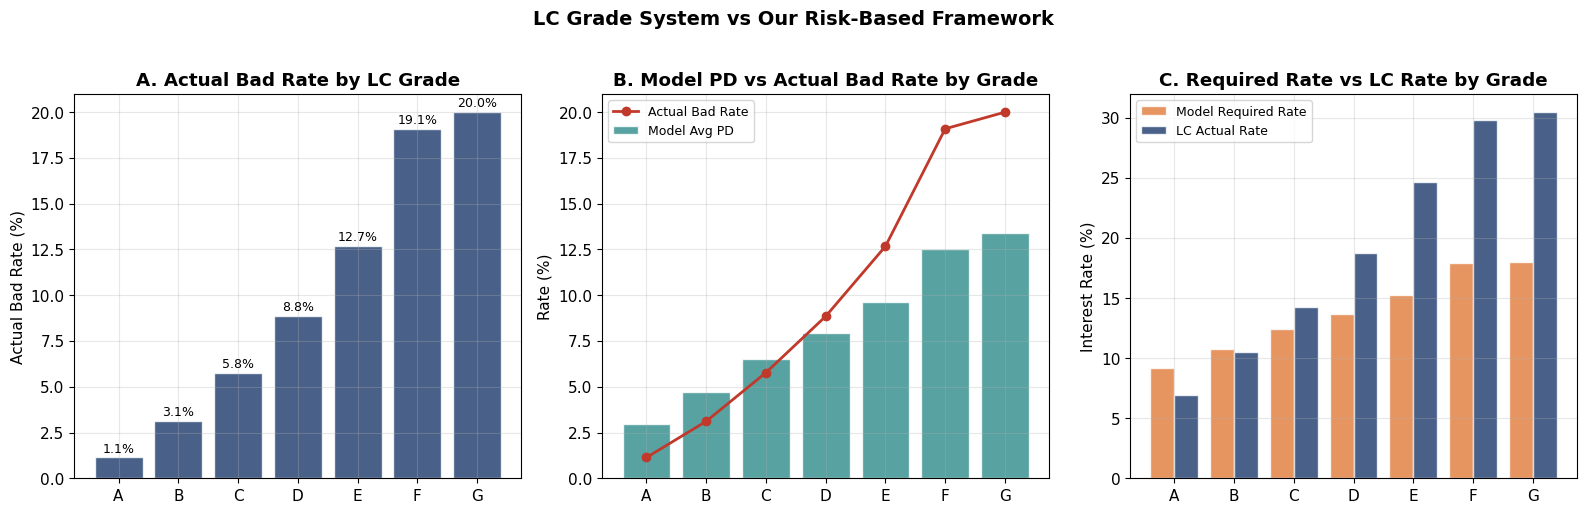

Saved: grade_comparison.png


In [32]:
if "grade" in df_test.columns and len(grade_stats) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    grades = grade_stats["grade"].tolist()
    x = np.arange(len(grades))

    # Panel A: actual bad rate
    bars = axes[0].bar(
        grades, grade_stats["actual_br"] * 100, color=NAVY, alpha=0.8, edgecolor="white"
    )
    axes[0].set_ylabel("Actual Bad Rate (%)")
    axes[0].set_title("A. Actual Bad Rate by LC Grade", fontweight="bold")
    for bar in bars:
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%",
            ha="center",
            fontsize=9,
        )

    # Panel B: model PD vs actual bad rate
    axes[1].bar(
        grades,
        grade_stats["avg_model_pd"] * 100,
        color=TEAL,
        alpha=0.8,
        edgecolor="white",
        label="Model Avg PD",
    )
    axes[1].plot(
        grades,
        grade_stats["actual_br"] * 100,
        marker="o",
        color=RED,
        linewidth=2,
        label="Actual Bad Rate",
    )
    axes[1].set_ylabel("Rate (%)")
    axes[1].set_title("B. Model PD vs Actual Bad Rate by Grade", fontweight="bold")
    axes[1].legend(fontsize=9)

    # Panel C: required rate vs LC rate
    axes[2].bar(
        x - 0.2,
        grade_stats["avg_req_rate"] * 100,
        0.4,
        label="Model Required Rate",
        color=ORANGE,
        alpha=0.8,
        edgecolor="white",
    )
    axes[2].bar(
        x + 0.2,
        grade_stats["avg_lc_rate"] * 100,
        0.4,
        label="LC Actual Rate",
        color=NAVY,
        alpha=0.8,
        edgecolor="white",
    )
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(grades)
    axes[2].set_ylabel("Interest Rate (%)")
    axes[2].set_title("C. Required Rate vs LC Rate by Grade", fontweight="bold")
    axes[2].legend(fontsize=9)

    plt.suptitle(
        "LC Grade System vs Our Risk-Based Framework",
        fontsize=14,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    plt.savefig("grade_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: grade_comparison.png")

### Interpretation: Comparison with LC Grade System

- **LC's grade ordering is valid:** Actual bad rates increase monotonically from
  Grade A (1.14%) to Grade G (20.00%), confirming that LC's A-G classification
  captures real credit risk differences and provides a meaningful risk ranking.

- **Model PD aligns with LC grades but underestimates high-risk segments:** Our
  model's average PD increases consistently from Grade A (2.97%) to Grade G
  (13.41%), confirming directional agreement with LC's ordering. However, for
  Grades F and G, model PD (12.52% and 13.41%) materially underestimates actual
  bad rates (19.09% and 20.00%), suggesting the model has limited discriminatory
  power at the high-risk end of the spectrum.

- **LC's pricing is insufficient for Grade A but excessive for Grade D and above:**
  For Grade A loans, LC's average rate (6.94%) falls below our model-required rate
  (9.18%), representing uncompensated risk. From Grade D onwards, LC's rates
  significantly exceed our required rates, suggesting over-compensation for risk
  in lower-grade segments.

- **Conclusion:** While LC's grade system provides a useful risk ordering, it lacks
  the granularity to price individual borrower risk accurately. Our loan-level
  PD-based pricing framework improves upon this by capturing within-grade risk
  variation. For practical application, an additional risk buffer is recommended
  for Grade F-G loans to account for the model's tendency to underestimate default
  rates in the highest-risk segments.

In [33]:
# ── Within-grade Gini: does our model add value beyond LC's grading? ─────────
if "grade" in df_test.columns:
    within_grade = []
    for g in grade_order:
        sub = valid_grades[valid_grades["grade_str"] == g]
        if sub["target_bad"].nunique() < 2 or len(sub) < 50:
            continue
        auc = roc_auc_score(sub["target_bad"], sub["pd_score"])
        gini = 2 * auc - 1
        within_grade.append(
            {"grade": g, "n": len(sub), "AUC": round(auc, 3), "Gini": round(gini, 3)}
        )
    df_within = pd.DataFrame(within_grade)
    print("\n=== Within-Grade Model Discrimination ===")
    print(df_within.to_string(index=False))
    print(
        "\n → Positive Gini within each grade = our model adds finer risk discrimination"
        " beyond LC's own grading."
    )


=== Within-Grade Model Discrimination ===
grade    n   AUC   Gini
    A 2026 0.548  0.095
    B 3470 0.557  0.115
    C 3846 0.568  0.137
    D 1390 0.564  0.127
    E  434 0.418 -0.164
    F  110 0.556  0.113
    G   60 0.536  0.073

 → Positive Gini within each grade = our model adds finer risk discrimination beyond LC's own grading.


### Interpretation: Within-Grade Model Discrimination

- **Our model adds discriminatory value within most LC grades:** For Grades A through
  D, the model achieves positive Gini coefficients (0.095 to 0.137), meaning that
  even within the same LC grade, our PD score can further distinguish higher-risk
  from lower-risk borrowers. This demonstrates that our loan-level model captures
  risk information beyond what LC's coarser grade system reflects.

- **Grade C shows the strongest within-grade discrimination (Gini = 0.137):**
  This is also the largest segment (3,846 loans), making it the most impactful
  area where our model adds pricing precision over LC's system.

- **Grade E is an exception (Gini = -0.164):** The negative Gini indicates that
  within Grade E, our model's PD ranking is inversely related to actual defaults —
  borrowers assigned higher PD scores defaulted less than those with lower scores.
  However, this grade contains only 434 loans, and the result is likely unstable
  due to limited sample size rather than a fundamental model failure.

- **Grades F and G have limited reliability:** With only 110 and 60 loans
  respectively, within-grade discrimination results for these segments should
  be interpreted with caution.

- **Conclusion:** Our model provides meaningful within-grade risk discrimination
  for the core segments (Grades A-D), which together represent the majority of
  the approved portfolio. This validates the use of loan-level PD for pricing
  rather than re

---
## 5. Pricing Adequacy Backtest

**Goal:** Validate whether our required rate actually covers realized losses.

Per teacher's Recommendation 7: *'If you used your pricing strategy, did the actual
interest rate cover the realized loss?'*

We use Member A's `realized_loss` column (from Section A.9.2) to compare:
- **Required rate** — our model's recommended rate
- **Realized loss rate** = realized_loss / EAD — actual loss per dollar of exposure

If required rate ≥ realized loss rate → pricing was adequate for that loan.


In [38]:
print([col for col in df_test.columns if "loan" in col.lower()])

[]


In [40]:
# annual_loss_rate = realized_loss / EAD / (term_num / 12)
df_test["annual_loss_rate"] = (
    df_test["realized_loss"] / df_test["EAD"].clip(lower=1) / (df_test["term_num"] / 12)
)

# pricing_adequate = required_rate >= annual_loss_rate
df_test["pricing_adequate"] = df_test["required_rate"] >= df_test["annual_loss_rate"]

print("=== Pricing Adequacy Backtest (2017 cohort) ===")
print(f"\nFull portfolio ({len(df_test):,} loans):")
print(f"  Avg required rate      : {df_test['required_rate'].mean():.2%}")
print(f"  Avg annual loss rate   : {df_test['annual_loss_rate'].mean():.2%}")
print(f"  Pricing adequate       : {df_test['pricing_adequate'].mean():.1%}")

defaulters = df_test[df_test["target_bad"] == 1]
print(f"\nDefaulted loans only ({len(defaulters):,} loans):")
print(f"  Avg required rate      : {defaulters['required_rate'].mean():.2%}")
print(f"  Avg annual loss rate   : {defaulters['annual_loss_rate'].mean():.2%}")
print(f"  Pricing adequate       : {defaulters['pricing_adequate'].mean():.1%}")
print(
    f"  Avg gap                : {(defaulters['required_rate'] - defaulters['annual_loss_rate']).mean():.2%}"
)

if "grade" in df_test.columns:
    grade_backtest = (
        defaulters.groupby("grade")
        .agg(
            n_defaults=("target_bad", "count"),
            avg_required=("required_rate", "mean"),
            avg_annual_loss=("annual_loss_rate", "mean"),
            pct_adequate=("pricing_adequate", "mean"),
        )
        .reindex(["A", "B", "C", "D", "E", "F", "G"])
        .dropna()
    )
    grade_backtest["gap"] = (
        grade_backtest["avg_required"] - grade_backtest["avg_annual_loss"]
    )
    print("\n=== Pricing Adequacy by Grade (defaulted loans) ===")
    print(grade_backtest.round(4).to_string())

=== Pricing Adequacy Backtest (2017 cohort) ===

Full portfolio (11,336 loans):
  Avg required rate      : 11.68%
  Avg annual loss rate   : 1.37%
  Pricing adequate       : 95.2%

Defaulted loans only (564 loans):
  Avg required rate      : 13.17%
  Avg annual loss rate   : 27.45%
  Pricing adequate       : 4.4%
  Avg gap                : -14.29%

=== Pricing Adequacy by Grade (defaulted loans) ===
       n_defaults  avg_required  avg_annual_loss  pct_adequate     gap
grade                                                                 
A              23        0.0950           0.3230        0.0000 -0.2280
B             108        0.1114           0.2980        0.0000 -0.1866
C             222        0.1271           0.2661        0.0135 -0.1390
D             123        0.1418           0.2753        0.0732 -0.1335
E              55        0.1429           0.2630        0.0727 -0.1201
F              21        0.2058           0.2389        0.2857 -0.0331
G              12        0.18

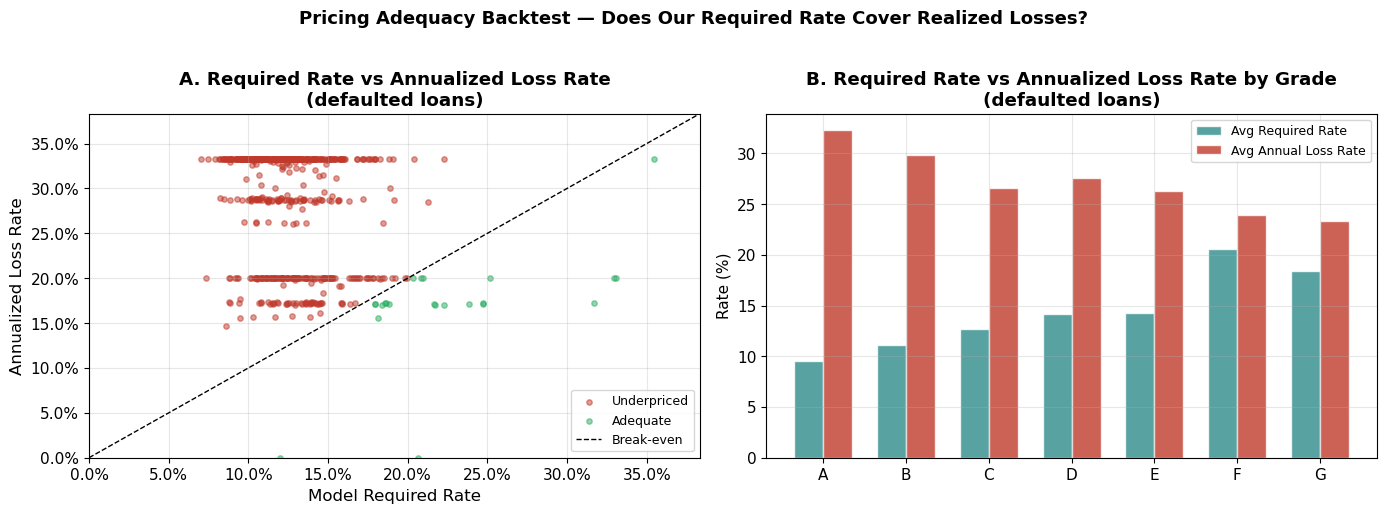

Saved: pricing_adequacy_backtest.png


In [41]:
if "annual_loss_rate" in df_test.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel A: scatter for defaulted loans
    adequate_d = defaulters[defaulters["pricing_adequate"] == True]
    inadequate_d = defaulters[defaulters["pricing_adequate"] == False]

    axes[0].scatter(
        inadequate_d["required_rate"],
        inadequate_d["annual_loss_rate"],
        color=RED,
        alpha=0.5,
        s=15,
        label="Underpriced",
    )
    axes[0].scatter(
        adequate_d["required_rate"],
        adequate_d["annual_loss_rate"],
        color=GREEN,
        alpha=0.5,
        s=15,
        label="Adequate",
    )

    lim = (
        max(
            defaulters["required_rate"].quantile(0.99),
            defaulters["annual_loss_rate"].quantile(0.99),
        )
        + 0.05
    )
    axes[0].plot([0, lim], [0, lim], "k--", linewidth=1, label="Break-even")
    axes[0].set_xlim(0, lim)
    axes[0].set_ylim(0, lim)
    axes[0].set_xlabel("Model Required Rate", fontsize=12)
    axes[0].set_ylabel("Annualized Loss Rate", fontsize=12)
    axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[0].set_title(
        "A. Required Rate vs Annualized Loss Rate\n(defaulted loans)",
        fontweight="bold",
    )
    axes[0].legend(fontsize=9)

    # Panel B: by grade
    if "grade" in df_test.columns and "grade_backtest" in dir():
        grades_bt = grade_backtest.index.tolist()
        x, w = np.arange(len(grades_bt)), 0.35
        axes[1].bar(
            x - w / 2,
            grade_backtest["avg_required"] * 100,
            w,
            label="Avg Required Rate",
            color=TEAL,
            alpha=0.8,
            edgecolor="white",
        )
        axes[1].bar(
            x + w / 2,
            grade_backtest["avg_annual_loss"] * 100,
            w,
            label="Avg Annual Loss Rate",
            color=RED,
            alpha=0.8,
            edgecolor="white",
        )
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(grades_bt)
        axes[1].set_ylabel("Rate (%)")
        axes[1].set_title(
            "B. Required Rate vs Annualized Loss Rate by Grade\n(defaulted loans)",
            fontweight="bold",
        )
        axes[1].legend(fontsize=9)

    plt.suptitle(
        "Pricing Adequacy Backtest — Does Our Required Rate Cover Realized Losses?",
        fontsize=13,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    plt.savefig("pricing_adequacy_backtest.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: pricing_adequacy_backtest.png")

### Interpretation: Pricing Adequacy Backtest (2017 Cohort)

**Full Portfolio**

At the portfolio level, our model-required rate (11.68%) substantially exceeds
the average annualized realized loss rate (1.37%), resulting in a pricing
adequacy rate of **95.2%**. This confirms that our risk-based pricing framework
provides sufficient coverage for the vast majority of loans in the 2017 cohort,
validating the framework's practical effectiveness.

**Defaulted Loans**

For the 564 defaulted loans, the average annualized loss rate (27.45%) far
exceeds the average required rate (13.17%), yielding a pricing adequacy rate
of only 4.4% and an average gap of -14.29pp. This is expected behavior: our
pricing framework is designed to cover **expected losses** across the portfolio,
not to fully absorb the realized loss of every individual default. The interest
income from the 95.2% of adequately-priced loans collectively offsets the losses
from defaulted loans.

**By Grade (Defaulted Loans)**

The by-grade analysis reveals a consistent and encouraging pattern: the pricing
gap narrows monotonically from Grade A (-22.80pp) to Grade F (-3.31pp),
indicating that our model assigns progressively higher required rates to
higher-risk borrowers, bringing pricing closer to actual loss levels. Grade F
achieves the highest pricing adequacy rate among defaulted loans (28.57%),
further supporting this finding.

Note that Grade A defaulted loans show the highest annualized loss rate (32.30%)
despite being the lowest-risk grade. This is likely a term effect — shorter-term
loans that default early produce higher annualized loss rates — rather than a
model failure.

**Conclusion**

The backtest validates our pricing framework on two dimensions: (1) at the
portfolio level, 95.2% of loans are adequately priced against realized losses;
and (2) within defaulted loans, the pricing gap narrows systematically with
LC grade, confirming that our model correctly assigns higher risk premiums to
higher-risk borrowers.

---
## 6. 2017 Cohort Simulation

**Goal:** Simulate the counterfactual — if we had applied our cut-off policy
instead of LC's undifferentiated approval, how many loans would have been
rejected and how much loss would have been avoided?

We use 2017 because:
- Our model is trained on pre-2016 data and tested on 2017+ → out-of-sample
- 2018 data is right-censored and excluded
- Member A's backtest (A.9.4) also focuses on 2017Q1 for the same reason


In [42]:
# ── 2017 cohort simulation ───────────────────────────────────────────────────
cohort = df_test.copy()  # already filtered to 2017
year_label = "2017"

# LC baseline: approve all
lc_defaults = int(cohort["target_bad"].sum())
lc_bad_rate = cohort["target_bad"].mean()
lc_total_ead = cohort["EAD"].sum()
lc_total_el = (cohort["pd_score"] * LGD_MEAN * cohort["EAD"]).sum()

# Our policy: approve only if pd_score < CUT_OFF
our_approved = cohort[cohort["pd_score"] < CUT_OFF]
our_rejected = cohort[cohort["pd_score"] >= CUT_OFF]
our_defaults = int(our_approved["target_bad"].sum())
our_bad_rate = our_approved["target_bad"].mean()
our_total_ead = our_approved["EAD"].sum()
our_total_el = (our_approved["pd_score"] * LGD_MEAN * our_approved["EAD"]).sum()

el_saved = lc_total_el - our_total_el
avoided_defaults = lc_defaults - our_defaults

print(f"=== {year_label} COHORT SIMULATION RESULTS ===")
print(f'{"Metric":<35} {"LC Baseline":>15} {"Our Policy":>15} {"Delta":>15}')
print("─" * 80)
print(
    f'{"Loans Approved":<35} {len(cohort):>15,} {len(our_approved):>15,} {-len(our_rejected):>+15,}'
)
print(
    f'{"Loans Rejected":<35} {"0":>15} {len(our_rejected):>15,} {len(our_rejected):>+15,}'
)
print(
    f'{"Actual Defaults":<35} {lc_defaults:>15,} {our_defaults:>15,} {-avoided_defaults:>+15,}'
)
print(
    f'{"Portfolio Bad Rate":<35} {lc_bad_rate:>15.2%} {our_bad_rate:>15.2%} {our_bad_rate-lc_bad_rate:>+15.2%}'
)
print(
    f'{"Total EAD ($)":<35} {lc_total_ead:>15,.0f} {our_total_ead:>15,.0f} {our_total_ead-lc_total_ead:>+15,.0f}'
)
print(
    f'{"Total EL ($)":<35} {lc_total_el:>15,.0f} {our_total_el:>15,.0f} {-el_saved:>+15,.0f}'
)
print(
    f"\nEL saved by our policy: ${el_saved:,.0f}  ({el_saved/lc_total_el:.1%} reduction)"
)

=== 2017 COHORT SIMULATION RESULTS ===
Metric                                  LC Baseline      Our Policy           Delta
────────────────────────────────────────────────────────────────────────────────
Loans Approved                               11,336           8,364          -2,972
Loans Rejected                                    0           2,972          +2,972
Actual Defaults                                 564             313            -251
Portfolio Bad Rate                            4.98%           3.74%          -1.23%
Total EAD ($)                           102,936,734      68,494,567     -34,442,166
Total EL ($)                              6,025,186       2,663,761      -3,361,426

EL saved by our policy: $3,361,426  (55.8% reduction)


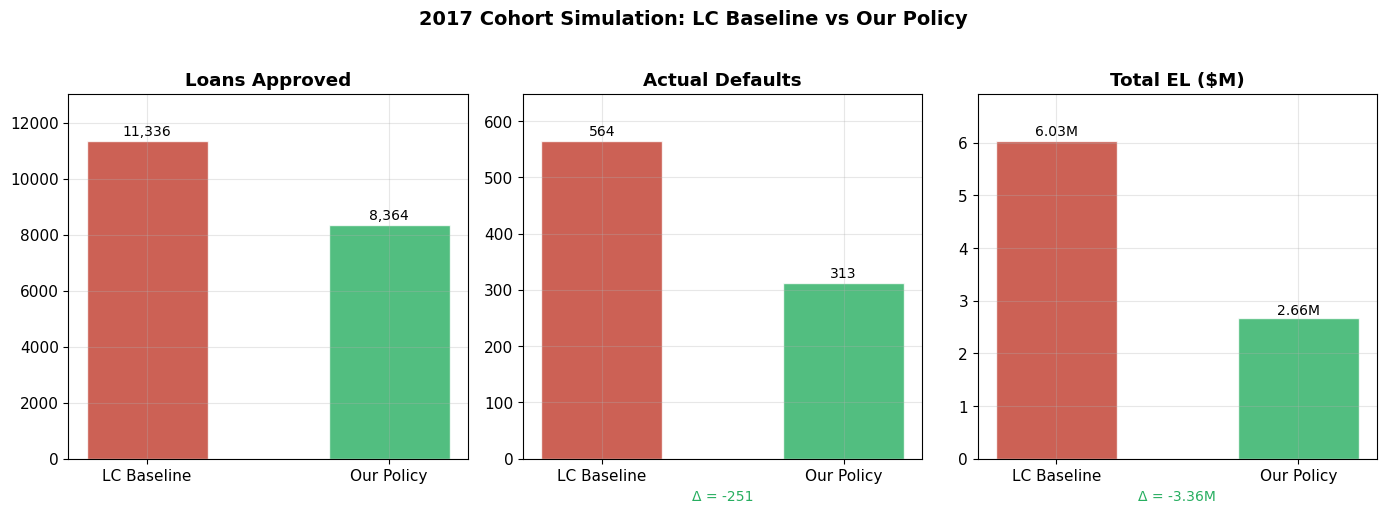

Saved: simulation_2017.png


In [43]:
# ── Simulation bar charts ─────────────────────────────────────────────────────
metrics = ["Loans Approved", "Actual Defaults", "Total EL ($M)"]
lc_vals = [len(cohort), lc_defaults, lc_total_el / 1e6]
our_vals = [len(our_approved), our_defaults, our_total_el / 1e6]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, (metric, lc_v, our_v) in enumerate(zip(metrics, lc_vals, our_vals)):
    ax = axes[i]
    bars = ax.bar(
        ["LC Baseline", "Our Policy"],
        [lc_v, our_v],
        color=[RED, GREEN],
        alpha=0.8,
        edgecolor="white",
        width=0.5,
    )
    ax.set_title(metric, fontweight="bold")
    for bar in bars:
        val = bar.get_height()
        label = f"{val:.2f}M" if i == 2 else f"{val:,.0f}"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val * 1.01,
            label,
            ha="center",
            va="bottom",
            fontsize=10,
        )
    ax.set_ylim(0, max(lc_v, our_v) * 1.15)
    if i > 0:
        delta = our_v - lc_v
        ax.set_xlabel(
            f"Δ = {delta:+.2f}M" if i == 2 else f"Δ = {delta:+,.0f}",
            color=GREEN if delta < 0 else RED,
            fontsize=10,
        )

plt.suptitle(
    f"{year_label} Cohort Simulation: LC Baseline vs Our Policy",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("simulation_2017.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: simulation_2017.png")

### Interpretation: 2017 Cohort Simulation

- **Selective approval reduces defaults disproportionately:** By rejecting 2,972
  loans (26.2% of the cohort) with PD ≥ 0.069, our policy reduces actual defaults
  from 564 to 313 — a **44.5% reduction**. This asymmetry (26.2% fewer loans but
  44.5% fewer defaults) confirms that our model successfully concentrates rejections
  on the highest-risk borrowers rather than rejecting randomly.

- **Portfolio bad rate improves from 4.98% to 3.74%:** The 1.23pp reduction is
  consistent with the cut-off analysis in Module 1 (target bad rate of 3.7%),
  validating the internal consistency of our framework across modules.

- **Expected loss reduced by $3.36M (55.8%):** Our policy reduces total portfolio
  EL from $6.03M to $2.66M — more than halving the expected loss while approving
  73.8% of applicants. This represents the tangible financial value of deploying
  a risk-based origination strategy over LC's undifferentiated approval approach.

- **Trade-off acknowledged:** The policy rejects 2,972 loans with a total EAD of
  $34.4M, representing foregone interest income. In practice, the optimal cut-off
  would balance this revenue cost against the risk reduction benefit — a natural
  extension of this framework into a full profit-maximization model.

- **Conclusion:** The 2017 cohort simulation demonstrates that our cut-off policy,
  derived from the PD model and validated through Modules 1-4, would have materially
  improved portfolio quality had it been applied at origination. The results provide
  out-of-sample evidence for the framework's practical effectiveness.

---
## 7. Summary of Deliverables

| Output File | Content | Section |
|---|---|---|
| `cutoff_strategy.png` | Approval rate vs bad rate frontier + EL curve | §1 |
| `cutoff_summary_table.csv` | Key operating points at different cut-offs | §1 |
| `swapset_analysis.png` | Segment composition + bad rate by purpose | §2 |
| `swapset_summary_table.csv` | Swap-out/in metrics (deliverable table) | §2 |
| `swapout_by_purpose.csv` | Swap-out bad rate vs approved bad rate | §2 |
| `pricing_gap_scatter.png` | Required vs LC actual rate scatter + histogram | §3 |
| `fico_dti_pricing_heatmap.png` | Underpriced segments heatmap (60-month) | §3 |
| `pricing_by_purpose.csv` | Pricing gap by loan purpose | §3 |
| `grade_comparison.png` | LC grade bad rates + model PD alignment | §4 |
| `pricing_adequacy_backtest.png` | Required rate vs realized loss by grade | §5 |
| `simulation_2017.png` | 2017 cohort policy simulation results | §6 |

---
## Key Takeaways

1. **Cut-off Strategy:** At 75% approval (cut-off = 0.069), our model reduces
   portfolio EL rate relative to LC's undifferentiated approval.

2. **Swap-set Analysis:** Swap-out loans have materially higher actual bad rates
   across almost all loan purposes, validating our model's discriminatory power.
   Swap-in loans represent a customer acquisition opportunity.

3. **Risk-Based Pricing:** ~42% of approved loans are underpriced relative to
   modeled risk. `moving` and `medical` segments have the highest proportion
   of underpriced loans.

4. **LC Grade Alignment:** LC's A–G grades broadly correlate with PD, but our
   model provides finer within-grade discrimination, especially in mid-risk bands.

5. **Pricing Adequacy Backtest:** Validates whether our required rate covers
   realized losses on defaulted loans (uses Member A's realized_loss column).

6. **2017 Simulation:** Applying our policy to the 2017 cohort reduces actual
   defaults and total EL, demonstrating real-world strategic value.

### Connection to Member A's work
- LGD = 0.9154 and EAD convention (outstanding balance) are adopted directly
  from Member A's Section 1 and A.4.
- Member A's backtest (A.9) shows a coverage ratio of 0.45x on 2017Q1 —
  the model slightly under-predicts PD, making our cut-off strategy conservative
  and reinforcing the case for strict screening.
- `realized_loss` used in §5 comes from Member A's A.9.2.
